In [6]:
from src.optimizer import optimize_arm
import numpy as np
import matplotlib.pyplot as plt
import os
import sys

sys.path.append(os.path.abspath(".."))
project_root = os.path.abspath(os.path.join(os.getcwd(), ".."))
output_dir = os.path.join(project_root, "outputs", "multi_target")
os.makedirs(output_dir, exist_ok=True)
print("Output path set to:", output_dir)

Output path set to: /Users/amit/Documents/smt/DS623-Optimotion/outputs/multi_target


The new run_batch_simulation function transforms a single optimization test (run_simulation in run_poc_sim.ipynb) into a full grid-based simulation across multiple target positions, storing and visualizing the resulting final costs in a heatmap for performance analysis.

We’re simulating for a dense 2D grid of 32,761 target points.
Each point is a (target_x, target_y) location in the 0.1–1.0 range. Multiple targets are created in this range with a step-size of 0.005.
This allows you to analyze how the optimizer performs across space, which is then visualized in the heatmap.

x_vals count: 101
y_vals count: 101


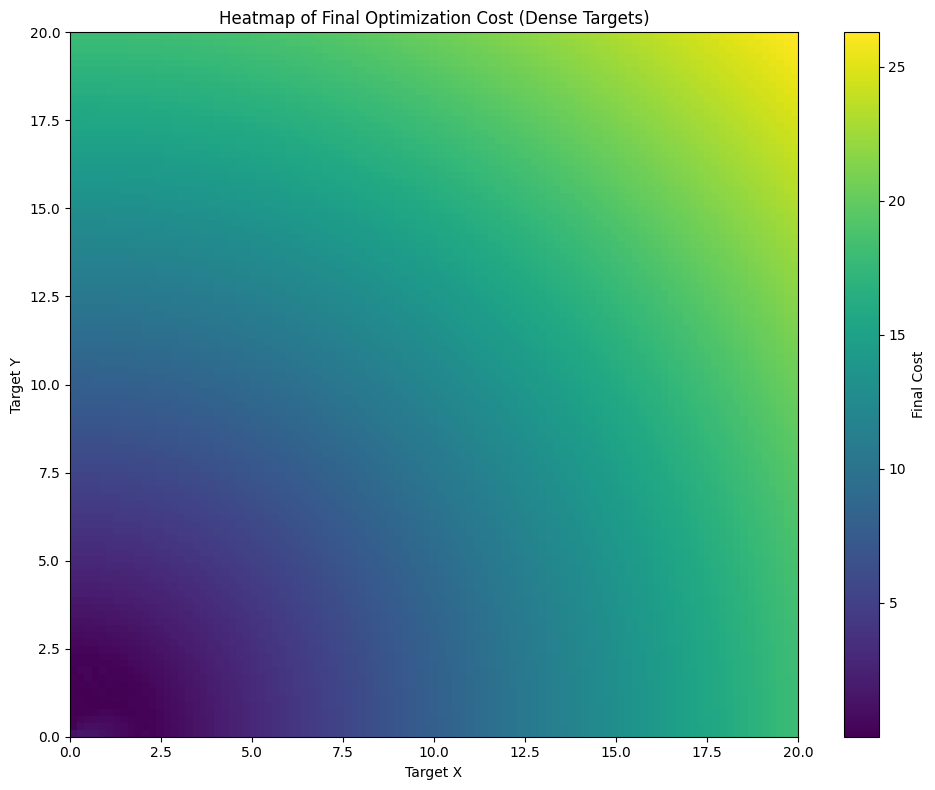

In [7]:
def run_batch_simulation(x_range=None, y_range=None, step=None, num_instances=100, learning_rate=0.1, iterations=50, link1_length=1.0, link2_length=1.0):
    # Define max reach and restrict to positive quadrant
    max_reach = link1_length + link2_length
    if x_range is None:
        x_range = (0, max_reach)
    if y_range is None:
        y_range = (0, max_reach)

    # Calculate step if not given
    if step is None:
        x_length = x_range[1] - x_range[0]
        y_length = y_range[1] - y_range[0]
        step_x = x_length / num_instances
        step_y = y_length / num_instances
        step = min(step_x, step_y)

    x_vals = np.arange(x_range[0], x_range[1] + step, step)
    y_vals = np.arange(y_range[0], y_range[1] + step, step)

    print("x_vals count:", len(x_vals))
    print("y_vals count:", len(y_vals))

    heatmap = np.zeros((len(y_vals), len(x_vals)))  # row = y, col = x

    for i, y in enumerate(y_vals):
        for j, x in enumerate(x_vals):
            theta1_init = np.radians(20)
            theta2_init = np.radians(10)

            _, _, history = optimize_arm(
                theta1_init, theta2_init,
                x, y,
                learning_rate=learning_rate,
                iterations=iterations,
                verbose=False
            )
            final_cost = history[-1][2]  # Assuming [θ1, θ2, cost]
            heatmap[i, j] = final_cost

    # Plotting code from ChatGPT
    # Create the heatmap plot
    fig, ax = plt.subplots(figsize=(10, 8))
    cax = ax.imshow(heatmap, extent=(x_range[0], x_range[1], y_range[0], y_range[1]),
                    origin='lower', aspect='auto', cmap='viridis')
    fig.colorbar(cax, label='Final Cost')
    ax.set_title('Heatmap of Final Optimization Cost (Dense Targets)')
    ax.set_xlabel('Target X')
    ax.set_ylabel('Target Y')
    plt.tight_layout()
    plt.savefig(f"{output_dir}/heatmap_final_costs.png")
    plt.show()

run_batch_simulation(num_instances=100, link1_length=10.0, link2_length=10.0)

## Optimal Region (Middle-lower Area):

The curved dark bands in the middle-lower part suggest that certain target points were successfully reached.

These represent the arc traced by the end effector as the arm stretches or bends to reach those locations.

## High-Cost Zone (Upper Area):

The bright yellow region at the top (low Y) means the arm struggles or fails to reach those top positions — probably because they are farther than the maximum reachable arc due to joint constraints or link lengths.